In [1]:
import sys
sys.path.append('../')
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pickle
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations
from utils.metrics import *
import random
import time
import os

from utils.metrics import RMSE
import utils.metrics as metrics
from simulators.ricker import ricker

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import warnings
warnings.filterwarnings('ignore')

/opt/homebrew/anaconda3/envs/robust-sbi/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
N = 100
NUM_SIMULATIONS = 1000
BATCH_SIZE = 200
T_RICKER = 100
SAMPLE_SIZE = 200

RICKER = "ricker"
QMC = "qmc"

In [3]:
# you can pre-generate the data using generate_data.py
x = torch.tensor(np.load(f"../data/{RICKER}_x_4000.npy")).reshape(4000, N, T_RICKER).to(device)
theta = np.load(f"../data/{RICKER}_theta_4000.npy")

x_qmc = torch.tensor(np.load(f"../data/{RICKER}_x_4000_{QMC}.npy")).reshape(4000, N, T_RICKER).to(device)
theta_qmc = np.load(f"../data/{RICKER}_theta_4000_{QMC}.npy")
u_qmc = torch.tensor(np.load(f"../data/{RICKER}_u_4000_{QMC}.npy")).to(device)

dataloader = DataLoader(x[:NUM_SIMULATIONS], batch_size=BATCH_SIZE, shuffle=True)
dataloader_qmc = DataLoader(x_qmc[:NUM_SIMULATIONS], batch_size=BATCH_SIZE, shuffle=True)

In [4]:
def regression_ABC(s_obs, param, sumStats, p):
    def mad(data):
        return np.mean(np.abs(data - np.mean(data, axis=0)), axis=0)

    if param.shape[0] < param.shape[1]:
        param = np.transpose(param)

    if sumStats.shape[0] < sumStats.shape[1]:
        sumStats = np.transpose(sumStats)
    
    M = len(param)
    M_epsilon = int(M*p)
    sumStats = sumStats
    s_obs = s_obs

    norm_factor = mad(sumStats)

    norm_sumStats = sumStats / norm_factor
    norm_s_obs = s_obs / norm_factor

    distance = np.linalg.norm(norm_sumStats - norm_s_obs, axis = 1)
    max_accepted_distance = np.sort(distance)[M_epsilon - 1]

    posterior_samples = param[distance <= max_accepted_distance, :]
    norm_sumStats_star = norm_sumStats[distance <= max_accepted_distance, :]

    weights = 1 - (distance[distance <= max_accepted_distance] / max_accepted_distance)**2
    W = np.diag(weights)

    s_obs_norm = np.tile(norm_s_obs, (M_epsilon,1))
    X = np.column_stack((np.ones(shape = (M_epsilon,1)), norm_sumStats_star - s_obs_norm))

    A = np.matmul(X.T, W)

    solution = np.linalg.solve(np.matmul(A, X), np.matmul(A, posterior_samples))

    beta = solution[1:,:]

    posterior_samples_adjusted = posterior_samples - np.matmul((norm_sumStats_star - s_obs_norm), beta)

    return posterior_samples_adjusted
    

In [5]:
class RickerSummary(nn.Module):
    def __init__(self, input_size, hidden_dim):
        super(RickerSummary, self).__init__()

        self.hidden_dim = hidden_dim
        self.input_size = input_size
        
        self.encoder = nn.Sequential(nn.Conv1d(self.input_size, 4, 3, 4),
                                     nn.Conv1d(4, 4, 3, 4),
                                     nn.Conv1d(4, 4, 3, 4),
                                     )
        
        self.decoder = nn.Sequential(nn.ConvTranspose1d(4, 4, 3, 4),
                                     nn.ConvTranspose1d(4, 4, 3, 4),
                                     nn.ConvTranspose1d(4, self.input_size, 3, 4),
                                     nn.Upsample(100)
                                     )

    def forward(self, Y):
        embeddings = self.encoder(Y.reshape(-1, 1, 100))
        output = self.decoder(embeddings.reshape(-1, 4, 1)).reshape(-1, N, 100)
        return output
    
    def forward_encoder(self, Y):
        embeddings = self.encoder(Y.reshape(-1, 1, 100)).reshape(-1, N, 4)
        return embeddings

# ABC

In [6]:
def solve_normal():
    summary_net_normal = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_normal.parameters(), lr=0.01)

    # Train the model for some number of epochs
    num_epochs = 10
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader:
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_normal(inputs)
            loss = criterion(outputs, inputs) / (N*T_RICKER)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_normal

# ABC-RS

In [7]:
def solve_robust(beta, obs_cont, sample_size):
    summary_net_robust = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_robust.parameters(), lr=0.01)

    index_list = [int(i) for i in range(len(x))]

    num_epochs = 10
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader:
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_robust(inputs)

            random.shuffle(index_list)
            context_embeddings = torch.mean(summary_net_robust.forward_encoder(x[index_list[:sample_size]]), dim=1)
            obs_embeddings = torch.mean(summary_net_robust.forward_encoder(obs_cont), dim=1)

            ae_loss = criterion(outputs, inputs) / (N*T_RICKER)
            summary_loss = metrics.MMD_unweighted(context_embeddings, obs_embeddings, lengthscale=metrics.median_heuristic(context_embeddings))

            loss = ae_loss + beta*summary_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_robust

# Efficient ABC-RS

In [8]:
def solve_robust_efficient(beta, obs_cont, sample_size):
    summary_net_robust = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_robust.parameters(), lr=0.01)

    index_list = [int(i) for i in range(len(x_qmc))]

    num_epochs = 10
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader_qmc:
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_robust(inputs)

            random.shuffle(index_list)
            theta = theta_qmc[index_list[:sample_size]]
            x = x_qmc[index_list[:sample_size]]
            u = u_qmc[index_list[:sample_size]]
                        
            context_embeddings = torch.mean(summary_net_robust.forward_encoder(x), dim=1)
            obs_embeddings = torch.mean(summary_net_robust.forward_encoder(obs_cont), dim=1)

            ae_loss = criterion(outputs, inputs) / (N*T_RICKER)
            
            u_flat = u.reshape(u.shape[0], -1).float()
            z = embedding_Gaussian(u_flat)
            w = computeWeights(u_flat, z)
            
            summary_loss = MMD_weighted(context_embeddings, obs_embeddings, w, lengthscale=metrics.median_heuristic(context_embeddings))

            loss = ae_loss + beta*summary_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_robust

# Main training loop

In [9]:
degrees = [0, 0.1, 0.2]

for degree in degrees:
    obs_cont = torch.tensor(np.load(f"../data/ricker_obs_{int(degree * 10)}.npy")).to(device)

    n_sims = 100
    beta_list = [1, 2, 3, 4, 5, 10]
    for beta in beta_list:
        for i in range(n_sims):
            print(f"Simulation {i}")
            summary_net_normal = solve_normal()
            s_normal = torch.mean(summary_net_normal.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_normal = torch.mean(summary_net_normal.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_normal = regression_ABC(s_obs_normal, theta, s_normal, 0.05)

            summary_net_robust = solve_robust(beta, obs_cont, SAMPLE_SIZE)
            s_robust = torch.mean(summary_net_robust.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_robust = torch.mean(summary_net_robust.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_robust = regression_ABC(s_obs_robust, theta, s_robust, 0.05)
            
            summary_net_robust_efficient = solve_robust_efficient(beta, obs_cont, SAMPLE_SIZE)
            s_robust_efficient = torch.mean(summary_net_robust_efficient.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_robust_efficient = torch.mean(summary_net_robust_efficient.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_robust_efficient = regression_ABC(s_obs_robust_efficient, theta, s_robust_efficient, 0.05)

            root_name = f'../objects/ABC/ricker_final/degree={degree}/lambda={beta}/' + str(i)
            if not os.path.exists(root_name):
                os.makedirs(root_name)
            np.save(root_name + '/posterior_normal.npy', posterior_normal)
            np.save(root_name + '/posterior_robust.npy', posterior_robust)
            np.save(root_name + '/posterior_robust_efficient.npy', posterior_robust_efficient)

Simulation 0
Epoch 1, Loss: 16.43681812286377
Epoch 2, Loss: 15.144460296630859
Epoch 3, Loss: 12.369961547851563
Epoch 4, Loss: 12.09328727722168
Epoch 5, Loss: 11.482334899902344
Epoch 6, Loss: 11.673595428466797
Epoch 7, Loss: 11.43363094329834
Epoch 8, Loss: 11.473575973510743
Epoch 9, Loss: 11.395764923095703
Epoch 10, Loss: 11.418941879272461
Epoch 1, Loss: 16.75135383605957
Epoch 2, Loss: 16.160262870788575
Epoch 3, Loss: 14.423094367980957
Epoch 4, Loss: 12.124418640136719
Epoch 5, Loss: 11.840406608581542
Epoch 6, Loss: 11.729624557495118
Epoch 7, Loss: 11.694400405883789
Epoch 8, Loss: 11.619904327392579
Epoch 9, Loss: 11.574517059326173
Epoch 10, Loss: 11.589314079284668
Epoch 1, Loss: 16.305630683898926
Epoch 2, Loss: 15.530681037902832
Epoch 3, Loss: 13.061778831481934
Epoch 4, Loss: 11.823878479003906
Epoch 5, Loss: 11.499701309204102
Epoch 6, Loss: 11.567902755737304
Epoch 7, Loss: 11.424450874328613
Epoch 8, Loss: 11.377211570739746
Epoch 9, Loss: 11.333043098449707
Epo

KeyboardInterrupt: 

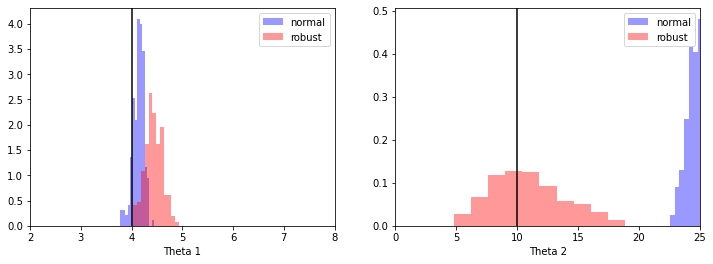

In [ ]:
posterior_normal = np.load("../objects/ABC/ricker_final/degree=0.2/lambda=3/13/posterior_normal.npy")
posterior_robust = np.load("../objects/ABC/ricker_final/degree=0.2/lambda=3/7/posterior_robust.npy")
posterior_robust_efficient = np.load("../objects/ABC/ricker_final/degree=0.2/lambda=3/7/posterior_robust_efficient.npy")

theta_gt = [4 ,10]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.axvline(x=theta_gt[0],ls="-",c="black")
sns.distplot(posterior_normal[:, 0], color='blue', kde=False, norm_hist=True, label="normal")
sns.distplot(posterior_robust[:, 0], color='red', kde=False, norm_hist=True, label="robust")
sns.distplot(posterior_robust_efficient[:, 0], color='green', kde=False, norm_hist=True, label="ours")
plt.legend()
plt.xlim(2, 8)
plt.xlabel("Theta 1")

plt.subplot(1, 2, 2)
plt.axvline(x=theta_gt[1],ls="-",c="black")
sns.distplot(posterior_normal[:, 1], color='blue', kde=False, norm_hist=True, label="normal")
sns.distplot(posterior_robust[:, 1], color='red', kde=False, norm_hist=True, label="robust")
sns.distplot(posterior_robust_efficient[:, 1], color='green', kde=False, norm_hist=True, label="ours")
plt.legend()
plt.xlim(0, 25)
plt.xlabel("Theta 2")

plt.show()

In [22]:
rmse_abc = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_normal), 2)
rmse_abc_rs = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_robust), 2)
rmse_abc_rs_e = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_robust_efficient), 2)

print(f"RMSE for ABC: {rmse_abc}")
print(f"RMSE for ABC-RS: {rmse_abc_rs}")
print(f"RMSE for Efficient ABC-RS: {rmse_abc_rs_e}")

RMSE for ABC: 10.51747176346229
RMSE for ABC-RS: 2.241420489998796


In [191]:
n_sims = 50
beta = 5
rmse_normal = np.zeros(n_sims)
rmse_robust = np.zeros(n_sims)
for i in range(n_sims):
    root_name = f'../objects/ABC/ricker/lambda={beta}/' + str(i)
    posterior_normal = torch.tensor(np.load(root_name + '/posterior_normal.npy'))
    posterior_robust = torch.tensor(np.load(root_name + '/posterior_robust.npy'))
    posterior_robust_efficient = torch.tensor(np.load(root_name + '/posterior_robust_efficient.npy'))
    rmse_normal[i] = RMSE(torch.tensor([4, 10]), posterior_normal, 2)
    rmse_robust[i] = RMSE(torch.tensor([4, 10]), posterior_robust, 2)
    rmse_robust_efficient[i] = RMSE(torch.tensor([4, 10]), posterior_robust_efficient, 2)

print("RMSE mean for normal model: ", np.mean(rmse_normal))
print("RMSE mean for robust model: ", np.mean(rmse_robust))
print("RMSE mean for efficient robust model: ", np.mean(rmse_robust_efficient))
print("RMSE std for normal model: ", np.std(rmse_normal))
print("RMSE std for robust model: ", np.std(rmse_robust))
print("RMSE std for efficient robust model: ", np.std(rmse_robust_efficient))

RMSE mean for normal model:  7.067988529761993
RMSE mean for robust model:  3.891314436146103
RMSE std for normal model:  0.3422907645779606
RMSE std for robust model:  1.1737282202563097
